# Experiment 7 figure generation and statistics

In [ ]:
import pickle as pkl
import pandas as pd
import numpy as np
from pathlib import Path

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
# So that we can edit the text in illustrator
# matplotlib.rcParams.update({'font.size': 10})

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

outdir = Path("rebuttal_figs")
outdir.mkdir(parents=True, exist_ok=True)


import seaborn as sns
from src import util_analysis 
from src import util_process_prolific as util_process
import re

## Plot main figure

##### Load data

In [2]:
results_dir = Path("final_results_dir")
human_df =  pd.read_csv(results_dir / "experiment_7_human_for_ANOVA.csv")

In [3]:
cmap = sns.color_palette('tab10', n_colors=8)
palette={}
palette[0] = cmap[7]
palette[90] = cmap[4]

In [4]:
human_df.loc[human_df.target_azim == 'block_front', 'target_azimuth'] = 0
human_df.loc[human_df.target_azim == 'block_ninety', 'target_azimuth'] = 90
human_df.target_azimuth = human_df.target_azimuth.astype(int)
human_df.head()

,participant,target_azim,distractor_offset,correct_mean,correct_count,confusions_mean,target_azimuth
0,participant_001,block_front,0,0.65,20,0.05,0
1,participant_001,block_front,10,0.65,20,0.00,0
2,participant_001,block_front,30,0.80,20,0.00,0
3,participant_001,block_front,90,0.95,20,0.00,0
4,participant_001,block_ninety,0,0.85,20,0.00,90


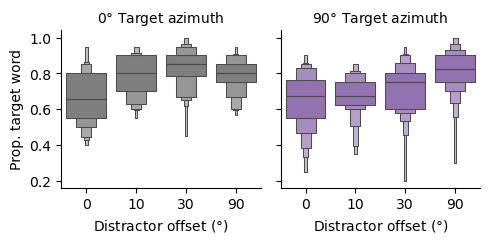

In [ ]:

g = sns.catplot(data=human_df,
                    x='distractor_offset',
                    y='correct_mean', 
                    col="target_azimuth",
                    hue="target_azimuth",
                    kind='boxen',
                    k_depth='full',
                    # zorder=3,
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    palette=palette,
                
                    height=2.5,
                    aspect=1,
                )
                    

g.set(
    # xticks=np.arange(-9, 7, 3), 
      xlabel='Distractor offset ($\degree$)',
      ylabel='Prop. target word',
    #   yticks=[0, 0.25, 0.5, 0.75, 1]
      )# c

g.set_titles("{col_name}$\degree$ Target azimuth")
# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

# plt.savefig(outdir / 'exp_7_participant_boxenplot.pdf', transparent=True,  bbox_inches='tight')


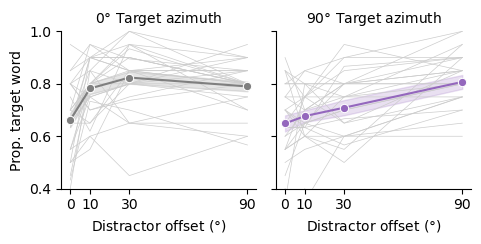

In [37]:

g = sns.relplot(data=human_df,
                    x='distractor_offset',
                    y='correct_mean', 
                    col="target_azimuth",
                    hue="target_azimuth",
                    kind='line',
                    errorbar=('se', 1),
                    marker='o',
                    # zorder=3,
                    # cut=0,
                    legend=False,
                    # inner="stick",
                    palette=palette,
                    height=2.5,
                    aspect=1,
                )
                    
for target_azim, ax in g.axes_dict.items():
    sns.lineplot(data=human_df[human_df.target_azimuth==target_azim],
                x='distractor_offset',
                y='correct_mean', 
                units='participant',
                estimator=None, 
                color=".8",
                linewidth=0.5,
                zorder=1,
                # alpha=0.,
                ax=ax,
                 )
    

g.set(
      xticks=human_df.distractor_offset.unique(), 
      xlabel='Distractor offset ($\degree$)',
      ylabel='Prop. target word',
      ylim=(0.4,1),
      )# c

g.set_titles("{col_name}$\degree$ Target azimuth")
# g.refline(y=0.5, linestyle='--', color='k', linewidth=0.75, alpha=0.5, zorder=1)

